# Simulate count data for viral variants

In [221]:
import numpy as np
import pandas as pd

from scipy.optimize import minimize

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from viral_variant_comp.simulate_count_data import create_count_data
from viral_variant_comp.plotting import plot_viral_composition, plot_confidence_intervals
from viral_variant_comp.estimate import calculate_viral_composition, evaluate_result, calculate_viral_composition_stepwise, reorder_variants

Assume that on average a new variant arises every 2 weeks: $r = 1/14$ with $\lambda = T \cdot r$. 

If for a variant only 0 counts are sampled, the variant is removed.

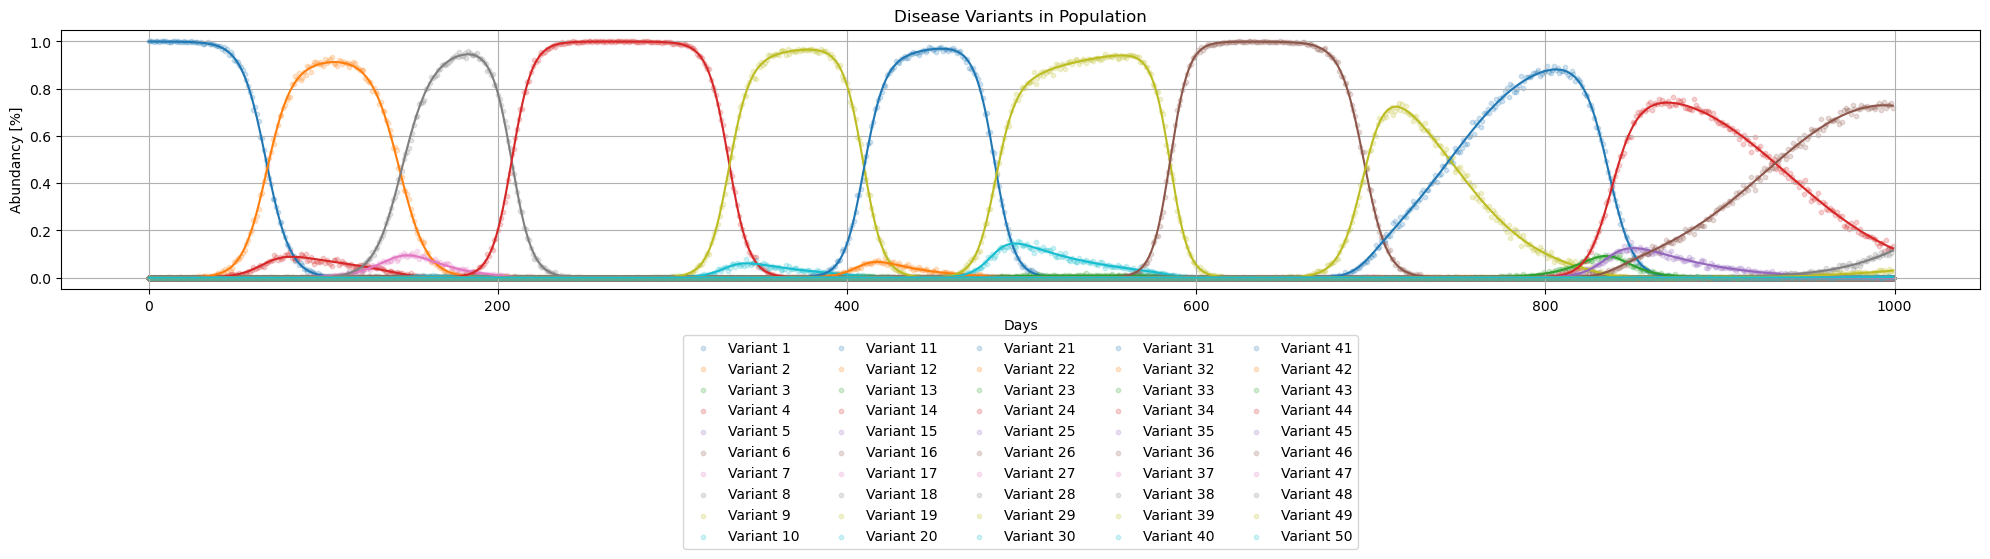

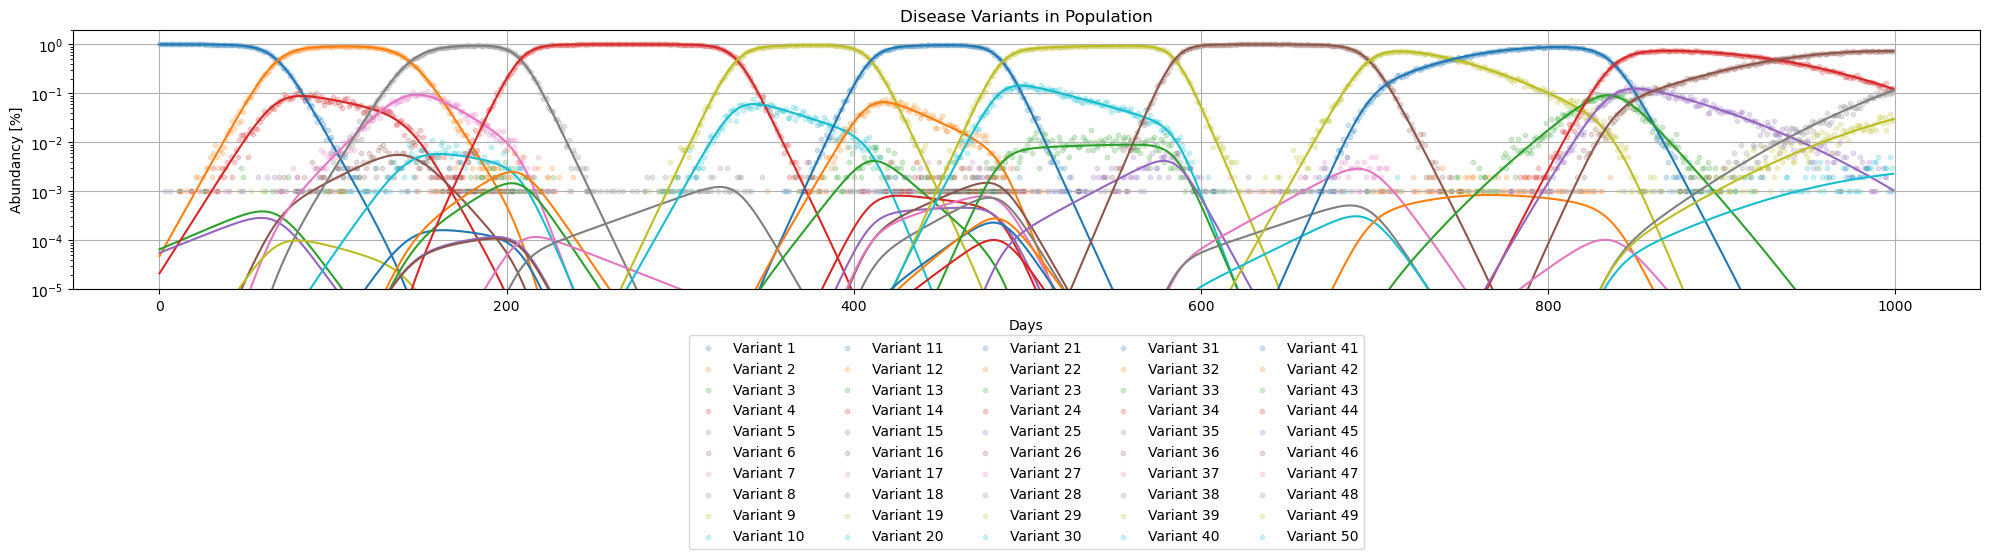

In [222]:
n_variants = 50
n_days = 1000
n_samples = 1000

delta_gr_range = 0.2
s_0 = 0.
o_0 = 0.
rate = 1/14  # per day, on average one new variant every two weeks
freq_entering_variants = 0.0001

data = create_count_data(n_variants = n_variants, n_days = n_days, delta_gr_range = delta_gr_range, new_var_rate = rate, freq_entering_variants = freq_entering_variants, n_samples = n_samples, s_0 = s_0, o_0 = o_0)
plot_viral_composition(data['counts'], data['freq'], n_samples, logscale = False)
plot_viral_composition(data['counts'], data['freq'], n_samples, y_range = (1e-5, 2), logscale = True)

# Use BFGS (Broyden-Fletcher-Goldfarb-Shanno algorithm) to numerically optimize likelihood function

Likelihood function (multinomial distr.):
$$
\mathcal{L}^{(t)}(s,o) = \mathbb{P}(c^{(t)} \mid p^{(t)}) = \frac{N_t!}{\prod_{i=1}^{n} c_i^{(t)}!} \prod_{i=1}^{n} p_i^{(t)^{c_i^{(t)}}}

$$

Log-Likelihood function (over all t):
$$
\log \mathcal{L}(s,o) = \sum_{t=0}^{T} \left( \sum_{i=1}^{n} c_i^{(t)} \cdot \log p_i(t) \right) + \text{const.} = \sum_{t=0}^{T} \sum_{i=1}^{n} c_i^{(t)} \cdot \left[ s_i t + o_i - \log \left( \sum_{j=1}^{n} e^{s_j t + o_j} \right) \right] + \text{const.}
$$

Derivative:
$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial s_i} =
\sum_{t=0}^{T} c_i^{(t)} \cdot t
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

$$
\frac{\partial \log \mathcal{L}(s, o)}{\partial o_i} =
\sum_{t=0}^{T} c_i^{(t)} 
- \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i}}{\sum_{j=1}^{n} e^{s_j t + o_j}}
$$

where $N(t) = \sum_{i=0}^{n} c_i^{(t)} $

To avoid not having a clear solution because all parameters are just entering the likelihood as ratios, the growth rate and log. initial frequency of the first variant is fixed to 0.

In [223]:
data_reordered = reorder_variants(data)
result, composition_estimate = calculate_viral_composition(data_reordered['counts'])

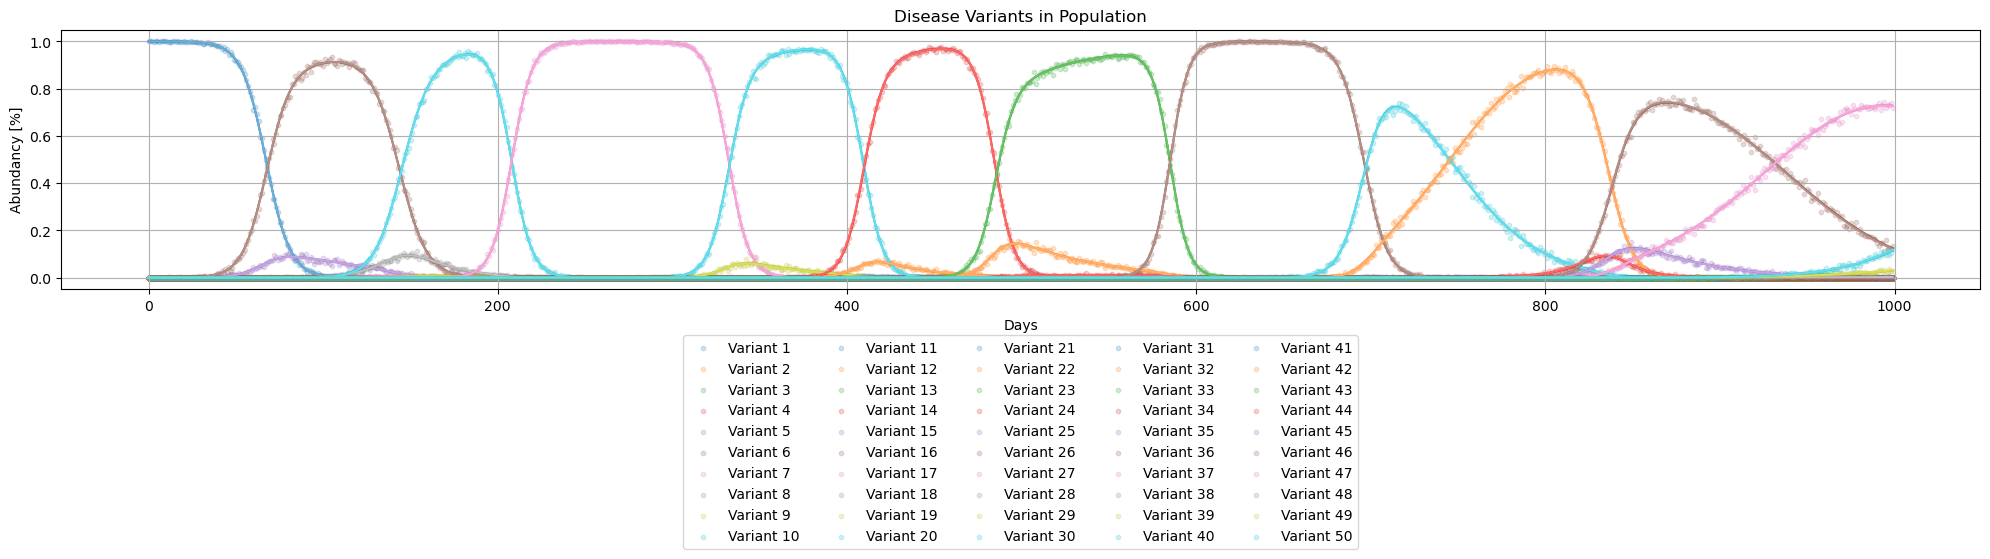

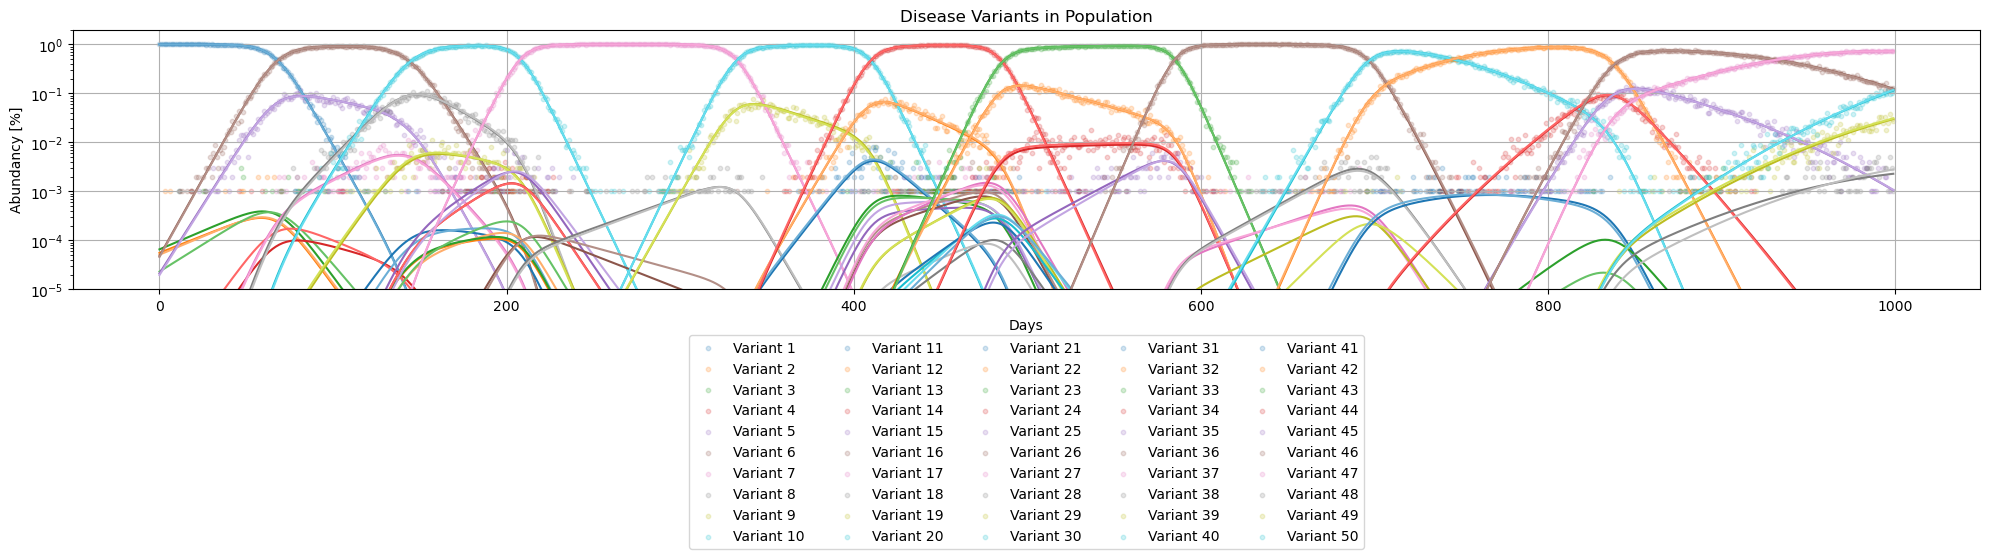

In [224]:
plot_viral_composition(data_reordered['counts'], data_reordered['freq'], n_samples, composition_estimate, logscale = False)
plot_viral_composition(data_reordered['counts'], data_reordered['freq'], n_samples, composition_estimate, y_range = (1e-5, 2), logscale = True)

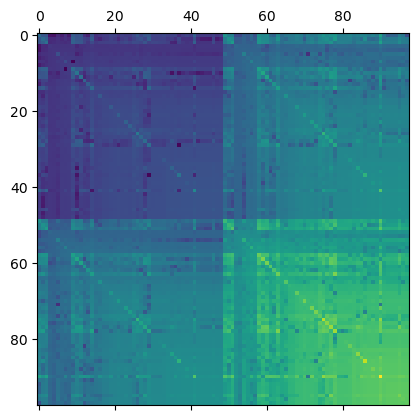

In [225]:
plt.matshow(np.log(np.abs(result.hess_inv)))


# Calculate Hessian

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \partial s_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t^2 \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t^2 \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial o_j}
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i^2}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot p_i \cdot (1 - p_i)
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_j}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_j} 
= \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \cdot e^{s_j t + o_j}}{\left( \sum_{k=1}^{n} e^{s_k t + o_k} \right)^2}
= \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot p_j
$$

$$
\frac{\partial^2 \log \mathcal{L}(\theta)}{\partial s_i \, \partial o_i}
= \frac{\partial^2 \log \mathcal{L}(\theta)}{\partial o_i \, \partial s_i}
= - \sum_{t=0}^{T} N(t) \cdot \frac{e^{s_i t + o_i} \cdot t \left( \sum_{j=1}^{n} e^{s_j t + o_j} - e^{s_i t + o_i} \right)}{\left( \sum_{j=1}^{n} e^{s_j t + o_j} \right)^2}
= - \sum_{t=0}^{T} N(t) \cdot t \cdot p_i \cdot (1 - p_i)
$$

In [242]:
counts = data['counts']
result, composition_estimate = calculate_viral_composition(data['counts'])

T, n = counts.shape

s_vec = result.x[:n]
o_vec = result.x[n:]
#s_vec = result_stepwise['growth_rate_estimate']
#o_vec = result_stepwise['log_init_freq_estimate']

t_vec = np.arange(T)
N_vec = np.sum(counts, axis = 1)

logits = np.outer(t_vec, s_vec) + o_vec     # shape T + 1 times n 
max_logits = np.max(logits, axis = 1)   # shape T
shifted_exp_logits = np.exp(logits - max_logits[:, np.newaxis])  # max_logits here vector of shape T+1 times 1
sum_shifted_exp_logits = np.sum(shifted_exp_logits, axis = 1)   # shape T
freq = shifted_exp_logits / sum_shifted_exp_logits[:, np.newaxis]

N_freq = N_vec[:, np.newaxis] * freq
N_t_freq = t_vec[:, np.newaxis] * N_freq
N_t2_freq = t_vec[:, np.newaxis] * N_t_freq
counter_freq = 1 - freq

d_si_sj = np.matmul(np.transpose(N_t2_freq), freq) # n times n
d_si_si = -np.sum(np.multiply(N_t2_freq, counter_freq), axis = 0) # n
np.fill_diagonal(d_si_sj, d_si_si)

d_oi_oj = np.matmul(np.transpose(N_t_freq), freq)
d_oi_oi = - np.sum(np.multiply(N_t_freq, counter_freq), axis = 1)
np.fill_diagonal(d_oi_oj, d_oi_oi)

d_oi_sj = np.matmul(np.transpose(N_freq), freq)
d_oi_si = - np.sum(np.multiply(N_freq, counter_freq), axis = 1)
np.fill_diagonal(d_oi_sj, d_oi_si)

top = np.hstack((d_si_sj, d_oi_sj))   # shape: (n, 2n)
bottom = np.hstack((d_oi_sj, d_oi_oj))  # shape: (n, 2n)

hessian = - np.vstack((top, bottom))  # shape: (2n, 2n)
neg_inv_hessian = np.linalg.inv(hessian)

In [243]:
np.linalg.eig(hessian)

EigResult(eigenvalues=array([ 5.02807242e+10,  2.74552877e+10,  9.74022072e+09,  7.91725693e+09,
        5.67486371e+09,  4.03131236e+09,  3.28332621e+09,  2.93226776e+09,
        2.22153896e+09,  1.85431009e+09,  1.16480767e+09,  8.67242254e+08,
        7.64821694e+08,  4.35785449e+08,  4.09964542e+08,  2.49838104e+08,
        2.15247415e+08,  1.62332289e+08,  1.15665154e+08,  7.77899415e+07,
        6.55181774e+07,  5.72468546e+07,  5.47066883e+07, -2.47901041e+07,
        2.90314832e+07,  2.73897288e+07,  2.40033741e+07, -1.55543727e+07,
        1.30840063e+07,  1.52418759e+07,  1.54606374e+07,  1.13454863e+07,
        1.07799345e+07,  9.96481764e+06,  9.36064916e+06, -5.26864207e+06,
        6.86385672e+06,  6.34524310e+06,  4.93164103e+06,  4.46178284e+06,
        4.94735037e+06,  3.97680835e+06, -2.84688425e+06,  2.84977934e+06,
        2.60100577e+06,  2.89254136e+06,  2.29234642e+06, -1.46029054e+06,
        1.44420956e+06,  1.03107850e+06, -6.51854929e+05,  8.95251763e+05,
   

In [226]:
counts = data['counts']
result, composition_estimate = calculate_viral_composition(data['counts'])

T, n = counts.shape

s_vec = result.x[:n]
o_vec = result.x[n:]
#s_vec = result_stepwise['growth_rate_estimate']
#o_vec = result_stepwise['log_init_freq_estimate']

t_vec = np.arange(T)
N_vec = np.sum(counts, axis = 1)

logits = np.outer(t_vec, s_vec) + o_vec     # shape T + 1 times n 
max_logits = np.max(logits, axis = 1)   # shape T
shifted_exp_logits = np.exp(logits - max_logits[:, np.newaxis])  # max_logits here vector of shape T+1 times 1
sum_shifted_exp_logits = np.sum(shifted_exp_logits, axis = 1)   # shape T
freq = shifted_exp_logits / sum_shifted_exp_logits[:, np.newaxis]

N_freq = N_vec[:, np.newaxis] * freq
N_t_freq = t_vec[:, np.newaxis] * N_freq
N_t2_freq = t_vec[:, np.newaxis] * N_t_freq
counter_freq = 1 - freq


N_t2_sum2 = N_times_t_vec_squared / squared_sum_shifted_exp_logits
N_t2_sum2_exp = np.multiply(shifted_exp_logits, N_t2_sum2[:,np.newaxis])    # T times n
sum_minus_exp = sum_shifted_exp_logits[:, np.newaxis] - shifted_exp_logits

d_si_sj = np.matmul(np.transpose(N_t2_sum2_exp), shifted_exp_logits) # n times n
d_si_si = -np.sum(np.multiply(N_t2_sum2_exp, sum_minus_exp), axis = 0) # n

np.fill_diagonal(d_si_sj, d_si_si)
upper_left = d_si_sj


N_sum2_exp = np.multiply(shifted_exp_logits, (N_vec / squared_sum_shifted_exp_logits)[:, np.newaxis])
d_oi_oj = np.matmul(np.transpose(N_sum2_exp), shifted_exp_logits)
d_oi_oi = - np.sum(np.multiply(N_sum2_exp, sum_minus_exp), axis = 1)

np.fill_diagonal(d_oi_oj, d_oi_oi)
bottom_right = d_oi_oj

N_t_sum2_exp = np.multiply(shifted_exp_logits, (N_t_vec / squared_sum_shifted_exp_logits)[:,np.newaxis])
d_oi_sj = np.matmul(np.transpose(N_t_sum2_exp), shifted_exp_logits)
d_oi_si = - np.sum(np.multiply(N_t_sum2_exp, sum_minus_exp), axis = 1)


np.fill_diagonal(d_oi_sj, d_oi_si)
bottom_left = d_oi_sj   # also upper_right

top = np.hstack((upper_left, bottom_left.T))   # shape: (n, 2n)
bottom = np.hstack((bottom_left, bottom_right))  # shape: (n, 2n)

hessian = np.vstack((top, bottom))  # shape: (2n, 2n)
neg_inv_hessian = - np.linalg.inv(hessian)

test_result = {"x":np.concatenate([s_vec, o_vec]), "hess_inv":neg_inv_hessian}

In [238]:
np.linalg.eig(hessian)

EigResult(eigenvalues=array([-5.02807356e+10, -2.74552964e+10, -9.74024420e+09, -7.91726294e+09,
       -5.67487396e+09, -4.03133045e+09, -3.28332936e+09, -2.93227783e+09,
       -2.22157543e+09, -1.85431456e+09, -1.16484500e+09, -8.67319562e+08,
       -7.64879655e+08, -4.37234328e+08, -4.10023292e+08, -2.50121404e+08,
       -2.16478510e+08, -1.62636446e+08, -1.15686954e+08, -7.32882499e+07,
       -6.34235997e+07, -5.72503520e+07, -5.46736354e+07, -4.28165647e+07,
       -2.94359668e+07, -2.06098752e+07,  1.09318496e+07, -1.52067680e+07,
       -1.33155066e+07, -1.18290829e+07, -1.07924719e+07, -1.01742532e+07,
       -9.34446428e+06, -7.83994980e+06, -6.47609854e+06, -5.91858738e+06,
       -4.56546481e+06, -4.34356195e+06, -3.77083987e+06, -2.75271159e+06,
       -2.53830643e+06, -2.22929478e+06, -8.66576493e+05, -6.82654241e+05,
        2.66772118e+05, -4.76463453e+05, -4.05516400e+05, -3.51723067e+05,
       -2.48588099e+05,  1.12854809e+05,  6.07260215e+04, -7.04591687e+04,
   

In [227]:
sum_shifted_exp_logits

array([1.00014038, 1.00015342, 1.00016813, 1.00018473, 1.00020351,
       1.00022478, 1.00024892, 1.00027634, 1.00030752, 1.00034304,
       1.00038354, 1.00042976, 1.00048256, 1.00054293, 1.00061202,
       1.00069114, 1.00078181, 1.00088579, 1.00100509, 1.00114206,
       1.00129939, 1.00148018, 1.00168802, 1.00192705, 1.00220205,
       1.00251854, 1.00288289, 1.00330245, 1.00378572, 1.00434248,
       1.00498408, 1.00572357, 1.00657606, 1.00755897, 1.00869246,
       1.00999977, 1.01150778, 1.01324751, 1.01525482, 1.01757112,
       1.02024425, 1.02332948, 1.02689068, 1.03100163, 1.0357476 ,
       1.04122708, 1.04755391, 1.05485964, 1.06329627, 1.07303949,
       1.08429231, 1.09728938, 1.1123019 , 1.1296433 , 1.1496759 ,
       1.17281847, 1.19955508, 1.23044531, 1.26613602, 1.30737501,
       1.35502681, 1.41009089, 1.47372279, 1.54725855, 1.63224293,
       1.73046208, 1.84398134, 1.97518897, 2.12684671, 2.01247912,
       1.89092293, 1.78568765, 1.69455282, 1.61560087, 1.54717

In [228]:
np.diag(neg_inv_hessian)

array([ 3.12629733e-08,  3.57168113e-09,  1.53653919e-05,  1.94642411e-08,
        2.19152139e-05,  2.03118346e-07,  9.63227496e-09,  1.96256183e-09,
        1.41943688e-05,  9.56078934e-08,  2.83815491e-06,  2.51910014e-07,
        4.39250782e-07,  1.05786048e-09,  2.46173996e-06,  4.02276896e-06,
        2.09548050e-06,  1.57810282e-07,  5.31151642e-10,  2.59806333e-09,
        3.77987584e-10,  1.81833750e-09,  3.48028797e-08,  9.33282443e-08,
        1.08113543e-07,  6.96136479e-08,  9.20186653e-08,  1.51365603e-07,
        2.16677140e-10,  4.69035840e-10,  3.93129201e-07,  3.62582363e-07,
        3.71444255e-09,  1.17455624e-06,  1.81148859e-08,  1.95285640e-10,
        1.86849268e-08,  8.29107984e-08,  7.01840358e-11,  2.31156490e-07,
        5.82544147e-11,  1.80493991e-08,  3.78312670e-10,  3.30644914e-11,
        1.76107834e-10,  3.84750231e-11,  2.00774044e-06,  3.37254339e-10,
        9.76996785e-10,  8.45095551e-09,  2.67623400e-04,  5.19467957e-05,
        2.96249764e+00,  

In [229]:
np.diag(result.hess_inv)

array([6.97307832e-07, 1.13383715e-04, 8.47182773e-07, 3.10430192e-05,
       6.11206970e-06, 1.29623652e-06, 1.18981441e-06, 1.84007401e-04,
       5.57445921e-06, 1.56828565e-04, 3.05014296e-05, 3.25522996e-05,
       2.47523263e-06, 1.01525555e-04, 2.96317701e-04, 1.10811356e-04,
       1.54945314e-05, 3.54426621e-06, 3.86648818e-06, 4.10116943e-06,
       4.57806564e-06, 1.99425510e-05, 3.27307229e-05, 3.71000778e-05,
       2.99561288e-05, 3.51488397e-05, 6.16119014e-05, 4.57838719e-06,
       4.65916107e-06, 2.85217315e-04, 2.26821951e-04, 5.51199167e-06,
       4.88158608e-04, 1.47612454e-05, 6.73595293e-06, 1.89539814e-05,
       4.06781967e-05, 7.86417590e-06, 2.50795411e-04, 7.92593806e-06,
       1.42386301e-05, 8.57190844e-06, 8.82513055e-06, 8.93693007e-06,
       8.82544027e-06, 1.62234959e-03, 9.33056811e-06, 9.82837647e-06,
       1.28949208e-05, 3.29045831e-03, 4.43727652e-01, 4.80489389e-03,
       1.62416553e-01, 9.90017738e-02, 1.58965901e-02, 1.36435331e-02,
      

# Evaluate fit of model

In [230]:
def evaluate_result_new(hess_inv, parameter_estimate, growth_rates, log_init_freq):

    true_params = np.concatenate([growth_rates, log_init_freq])
    print(true_params.shape)
    
    z = 1.96    # 95% confidence interval
    standard_errors =  z * np.sqrt(np.diag(hess_inv))
    lower_bounds = parameter_estimate - standard_errors
    upper_bounds = parameter_estimate + standard_errors

    deviations = result.x - true_params
    abs_deviations = np.abs(deviations)
    estimated_correctly = abs_deviations <= standard_errors

    df = pd.DataFrame({
        'parameter_estimate': parameter_estimate,
        'true_parameter': true_params,
        'deviation': deviations,
        'abs_deviation': abs_deviations,
        'estimated_correctly': estimated_correctly,
        'standard_error': standard_errors,
        'ci_lower': lower_bounds,
        'ci_upper': upper_bounds,
        'n_variants': np.repeat(parameter_estimate.shape[0] // 2, parameter_estimate.shape[0]),
        'parameter_type': np.concatenate([np.repeat('growth_rate', parameter_estimate.shape[0] // 2), np.repeat('log_initial_freq', parameter_estimate.shape[0] // 2)])
    })

    return df

(100,)


/var/folders/l3/cr7pvqjn2054djbp5cf7qbd40000gn/T/ipykernel_13930/4118631989.py:7: RuntimeWarning: invalid value encountered in sqrt
  standard_errors =  z * np.sqrt(np.diag(hess_inv))


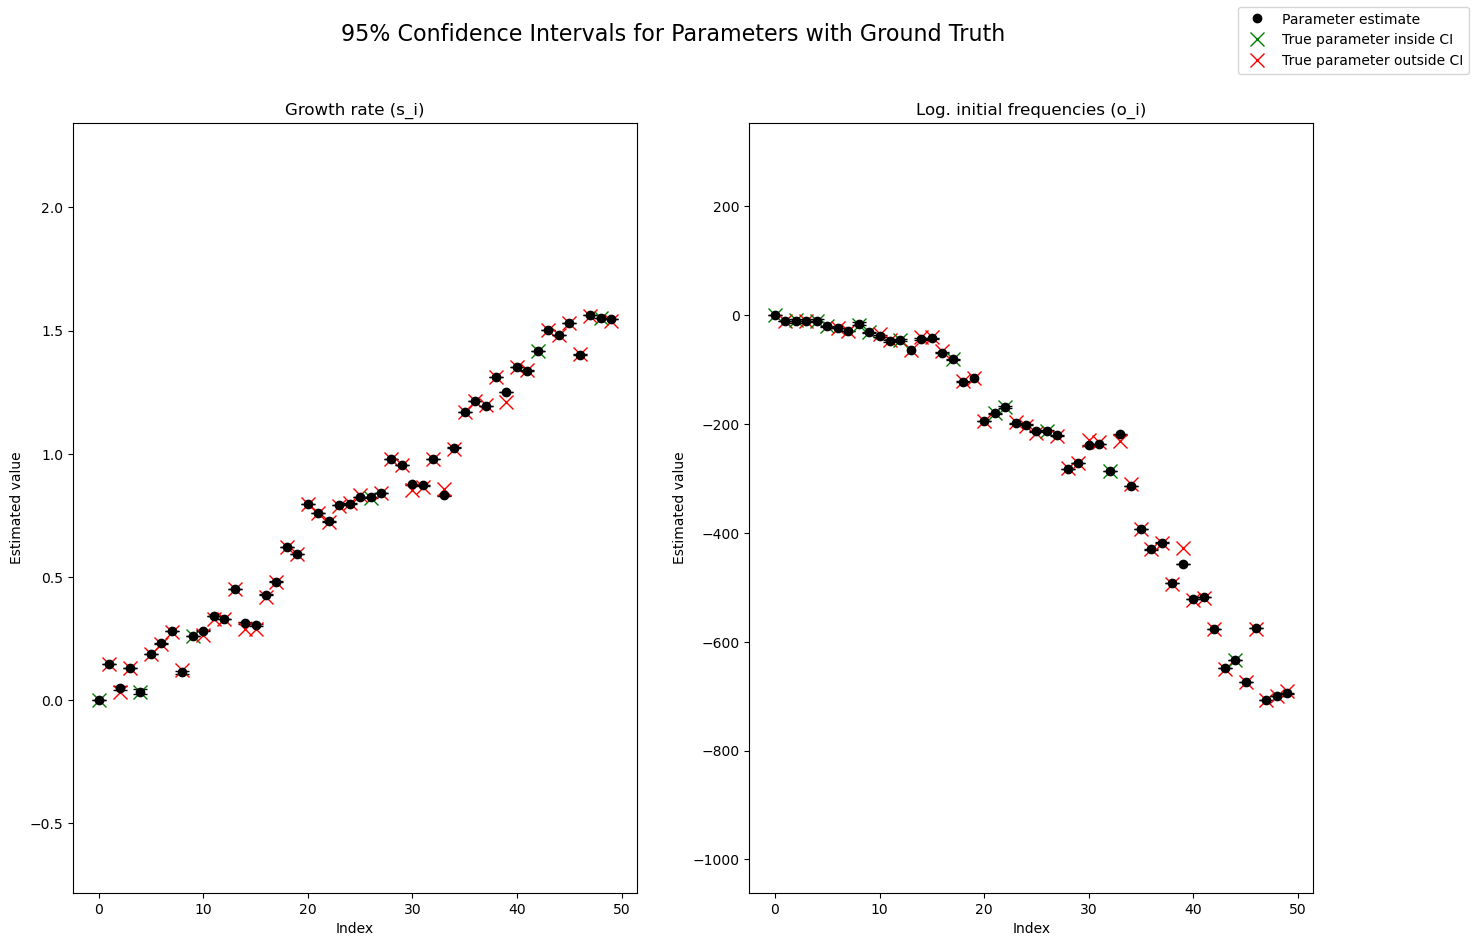

In [231]:
df_test = evaluate_result_new(neg_inv_hessian, np.concatenate([s_vec, o_vec]), data['growth_rates'], data['log_init_freq'])
plot_confidence_intervals(df_test)

(100,)


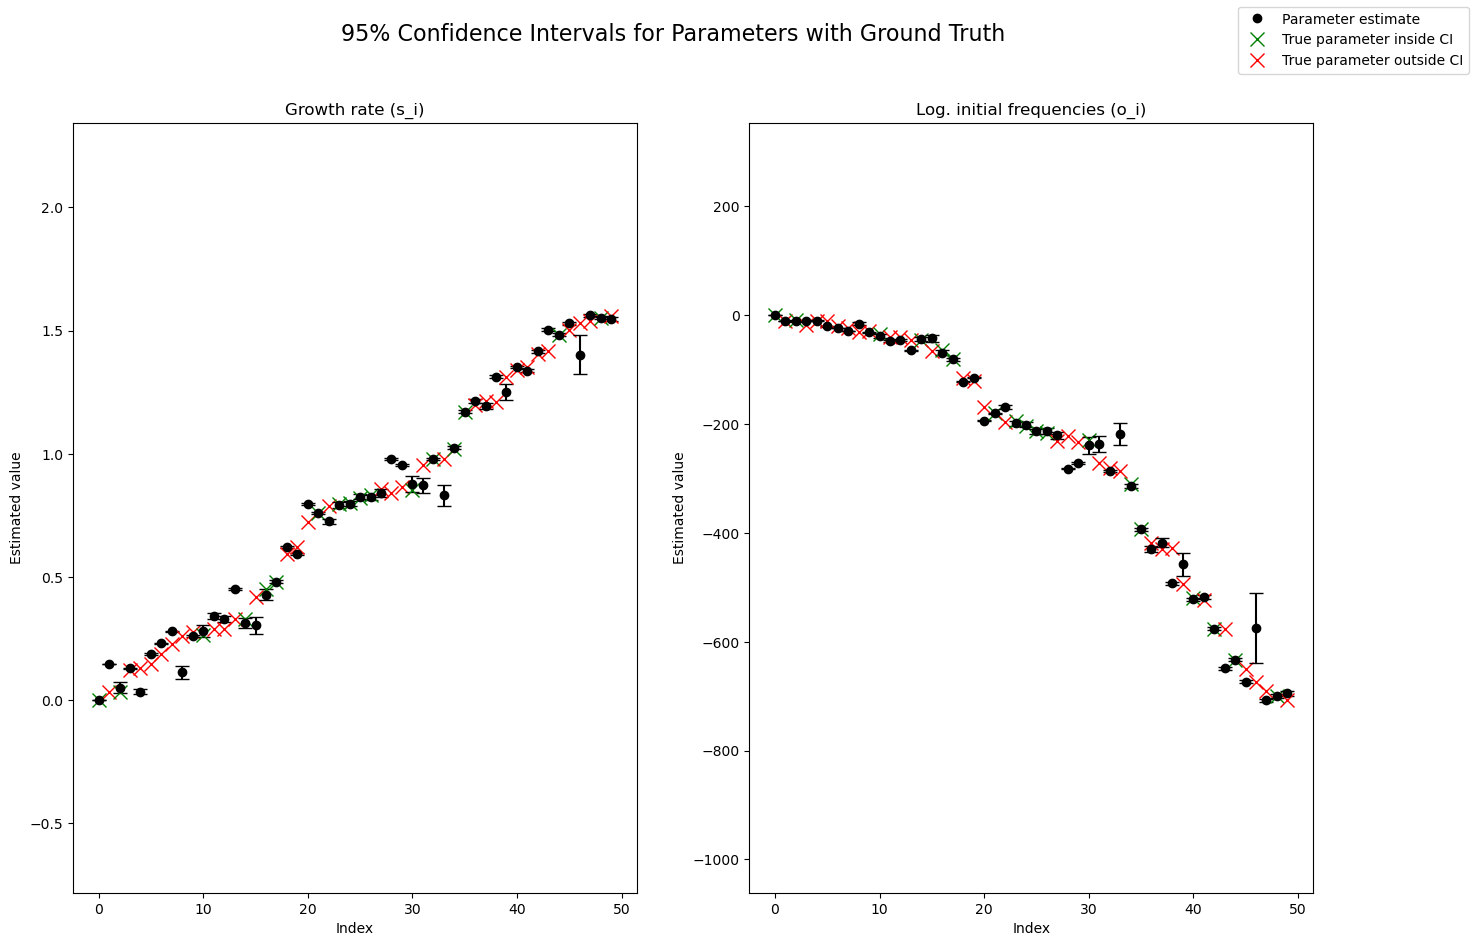

In [232]:
df = evaluate_result(result, data_reordered['growth_rates'], data_reordered['log_init_freq'])
plot_confidence_intervals(df)

# Estimate parameters stepwise

To estimate the parameters more effectively, we can use the fact, that variants, that have been present in the past will not arise again. That's why we can estimate the parameters in a stepwise manner, considering a fixed number of variants at a time.
The variants are ordered according to the timepoint of their peak (average time, weighted by abundance of viral variant). In each estimation step, an overlap size is chosen of variants whose parameter estimates enter the calculation of the next variant. The current algorithm needs at least an overlap of 1 to have one fixed parameter value as a reference.

Currently the variant parameters are estimated the first time they are part of the estimation window and are fixed afterwards.

loop  0
loop  1
loop  2
loop  3
loop  4


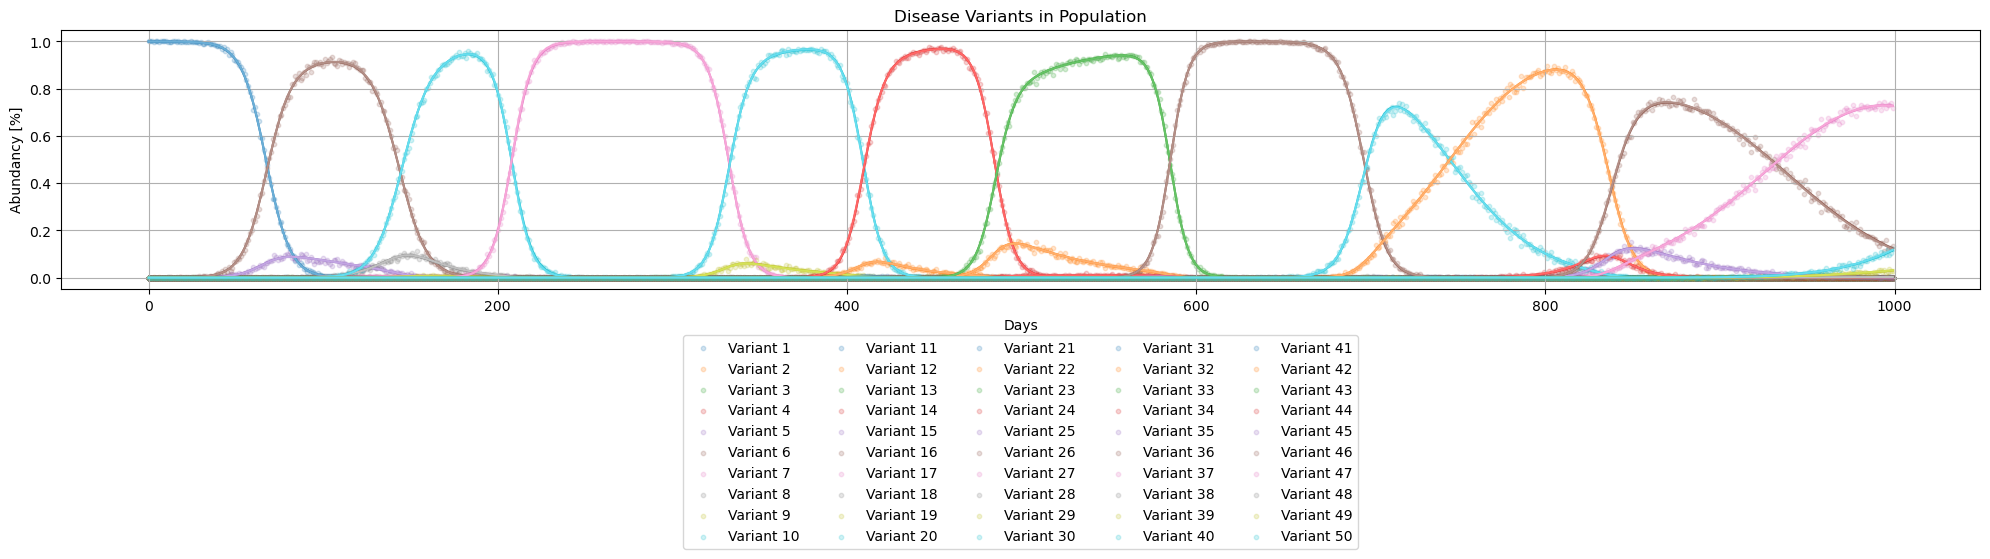

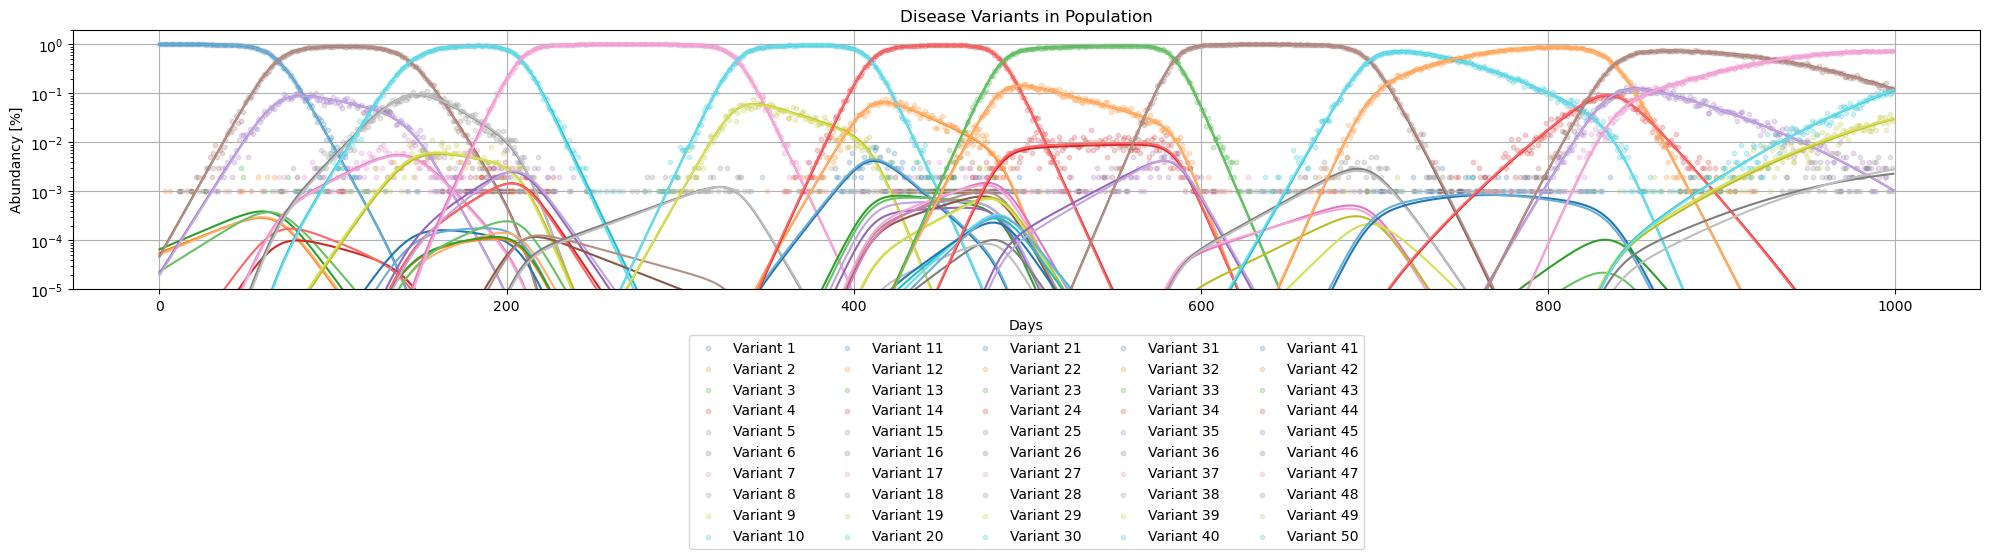

In [233]:
partition_size = 15
overlap_size = 4

result_stepwise = calculate_viral_composition_stepwise(data, partition_size, overlap_size)

plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], logscale = False)
plot_viral_composition(result_stepwise['reordered_data']['counts'], result_stepwise['reordered_data']['freq'], n_samples, result_stepwise['composition_estimate'], y_range = (1e-5, 2), logscale = True)

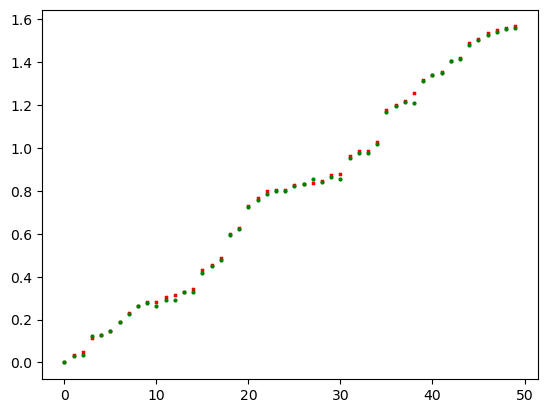

In [234]:
for i in range(result_stepwise['growth_rate_estimate'].shape[0]):
    plt.scatter(i, result_stepwise['growth_rate_estimate'][i], marker = 'x', s = 4, color = 'red')
    plt.scatter(i, result_stepwise['reordered_data']['growth_rates'][i], marker = 'o', s= 4, color = 'green')

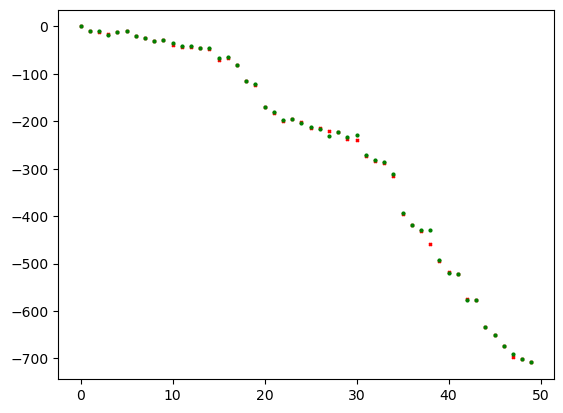

In [235]:
for i in range(result_stepwise['log_init_freq_estimate'].shape[0]):
    plt.scatter(i, result_stepwise['log_init_freq_estimate'][i], marker = 'x', s = 4, color = 'red')
    plt.scatter(i, result_stepwise['reordered_data']['log_init_freq'][i], marker = 'o', s= 4, color = 'green')